In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=["GarageQual","FireplaceQu","SalePrice"])

In [3]:
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
422,NaN,TA,113000
192,NaN,TA,192000
317,Gd,TA,270000
1310,TA,TA,335000
1208,NaN,TA,140000


In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

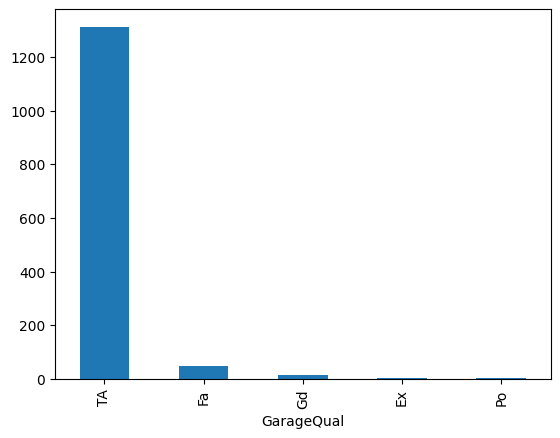

In [5]:
df["GarageQual"].value_counts().plot(kind="bar")
plt.show()

In [6]:
df["GarageQual"].mode()

0    TA
Name: GarageQual, dtype: object

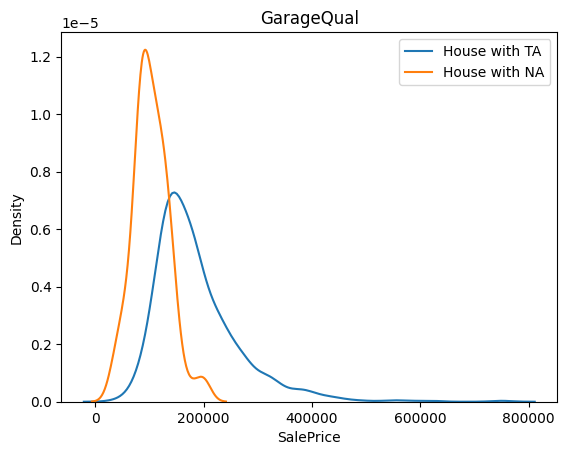

In [7]:
sns.kdeplot(df[df["GarageQual"]=="TA"]["SalePrice"], label="House with TA")

sns.kdeplot(df[df["GarageQual"].isnull()]["SalePrice"], label="House with NA")

plt.title("GarageQual")
plt.legend()
plt.show()

In [8]:
temp = df[df["GarageQual"]=="TA"]["SalePrice"]

In [9]:
df["GarageQual"] = df["GarageQual"].fillna("TA")

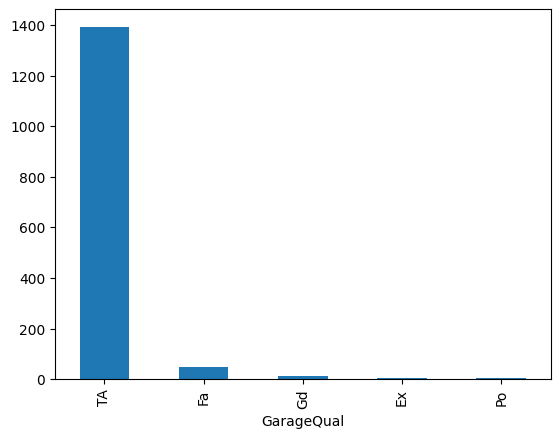

In [10]:
df["GarageQual"].value_counts().plot(kind="bar")
plt.show()

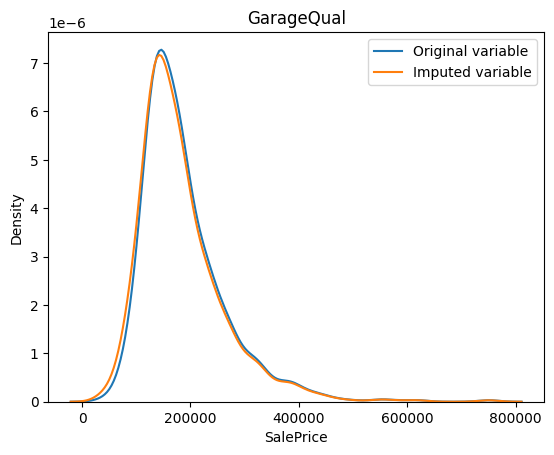

In [11]:
sns.kdeplot(temp, label="Original variable")

sns.kdeplot(df[df["GarageQual"]=="TA"]["SalePrice"], label="Imputed variable")

plt.title("GarageQual")
plt.legend()
plt.show()

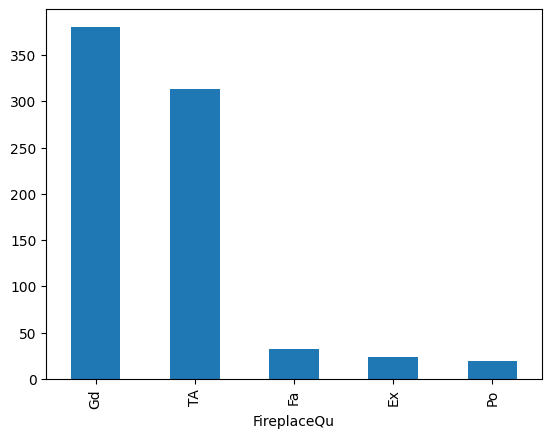

In [12]:
df["FireplaceQu"].value_counts().plot(kind="bar")
plt.show()

In [13]:
df["FireplaceQu"].mode()

0    Gd
Name: FireplaceQu, dtype: object

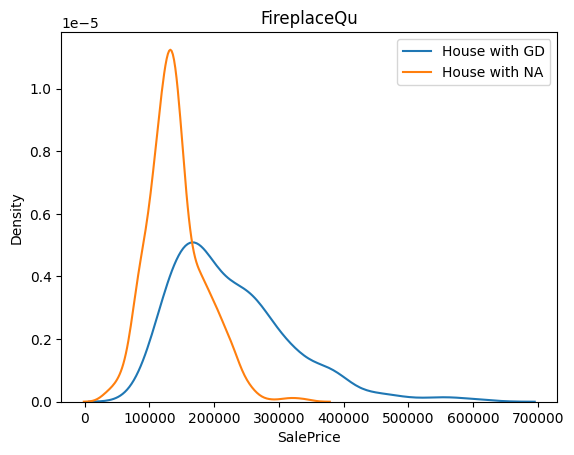

In [16]:
sns.kdeplot(df[df["FireplaceQu"]=="Gd"]["SalePrice"], label="House with GD")

sns.kdeplot(df[df["FireplaceQu"].isnull()]["SalePrice"], label="House with NA")

plt.title("FireplaceQu")
plt.legend()
plt.show()

In [17]:
temp = df[df["FireplaceQu"]=="Gd"]["SalePrice"]

In [19]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("Gd")

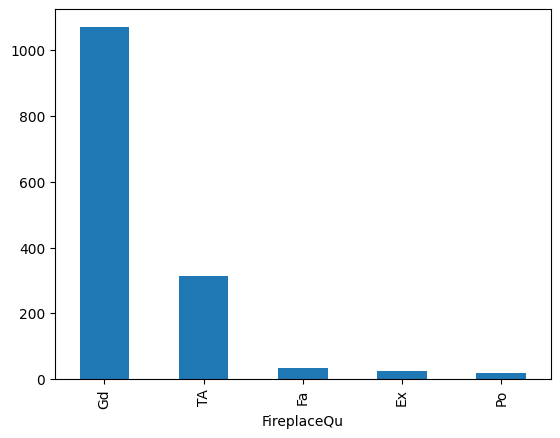

In [21]:
df["FireplaceQu"].value_counts().plot(kind="bar")
plt.show()

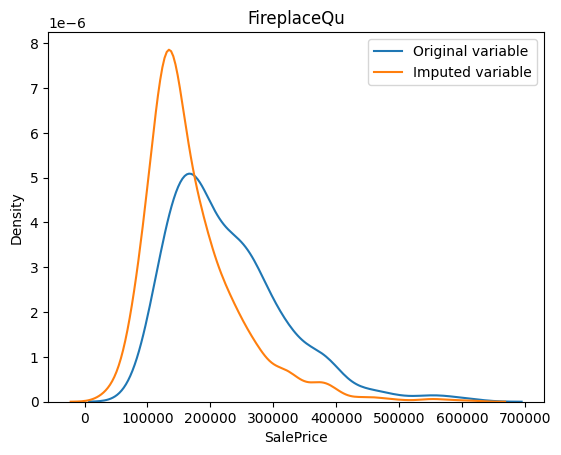

In [22]:
sns.kdeplot(temp, label="Original variable")

sns.kdeplot(df[df["FireplaceQu"]=="Gd"]["SalePrice"], label="Imputed variable")

plt.title("FireplaceQu")
plt.legend()
plt.show()

Using Sklearn

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [24]:
from sklearn.impute import SimpleImputer

In [25]:
imputer = SimpleImputer(strategy='most_frequent')

In [27]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [28]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)